<a href="https://colab.research.google.com/github/SithmiDesilva/Hallucination-Aware-AI-Framework-for-Trustworthy-Supply-Chain-Decision-Intelligence.-/blob/M5_Forecasting_Preprocessing/M5_Forecasting_Calendar_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================================
# NOTEBOOK 1: CALENDAR DATASET PREPROCESSING FOR M5 FORECASTING
# ============================================================================
# This notebook handles the calendar.csv dataset from the M5 Forecasting competition
# It performs preprocessing, outlier detection, and data quality checks
# ============================================================================


# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

### SECTION 1: SETUP AND DATA LOADING

In [2]:
# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [3]:
# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the calendar dataset
# Adjust path as needed for your Google Drive structure
calendar = pd.read_csv('/content/drive/MyDrive/IRP/M5 Forecasting dataset/calendar.csv')

In [30]:

print(f"\nDataset Shape: {calendar.shape}")
print(f"Columns: {calendar.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(calendar.head())


Dataset Shape: (1969, 15)
Columns: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'date_temp']

First 5 rows:


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,date_temp
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,2011-01-29
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,2011-01-30
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,2011-01-31
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,2011-02-01
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,2011-02-02



### SECTION 2: INITIAL DATA EXPLORATION AND VISUALIZATION (BEFORE PREPROCESSING)




In [7]:
# 2.1 Basic Information
print("\n--- Data Types and Missing Values ---")
print(calendar.info())
print(f"\nMissing Values:")
print(calendar.isnull().sum())


--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB
None

Missing Values:
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
yea

In [8]:
# 2.2 Statistical Summary
print("\n--- Statistical Summary ---")
display(calendar.describe())


--- Statistical Summary ---


,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI
count,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000
mean,11347.086338,3.997461,6.325546,2013.288471,0.330117,0.330117,0.330117
std,155.277043,2.001141,3.416864,1.580198,0.470374,0.470374,0.470374
min,11101.000000,1.000000,1.000000,2011.000000,0.000000,0.000000,0.000000
25%,11219.000000,2.000000,3.000000,2012.000000,0.000000,0.000000,0.000000
50%,11337.000000,4.000000,6.000000,2013.000000,0.000000,0.000000,0.000000
75%,11502.000000,6.000000,9.000000,2015.000000,1.000000,1.000000,1.000000
max,11621.000000,7.000000,12.000000,2016.000000,1.000000,1.000000,1.000000


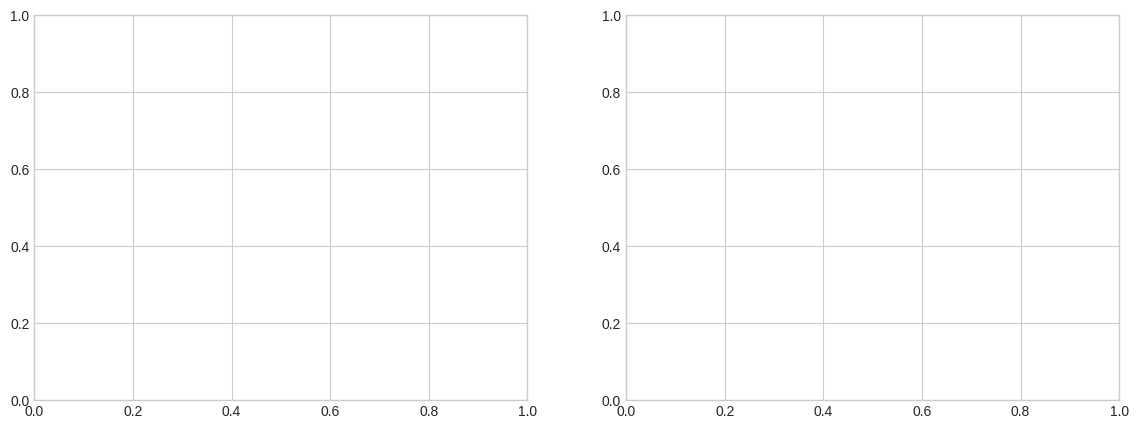

In [9]:
# 2.3 Visualize missing values before preprocessing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [10]:
# Missing values heatmap
missing_data = calendar.isnull().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    axes[0].barh(missing_data.index, missing_data.values, color='coral')
    axes[0].set_xlabel('Number of Missing Values')
    axes[0].set_title('Missing Values by Column (Before Preprocessing)')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values by Column')

In [11]:
# Date range visualization
calendar['date_temp'] = pd.to_datetime(calendar['date'])
axes[1].hist(calendar['date_temp'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Date Distribution (Before Preprocessing)')

plt.tight_layout()
plt.savefig('calendar_before_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

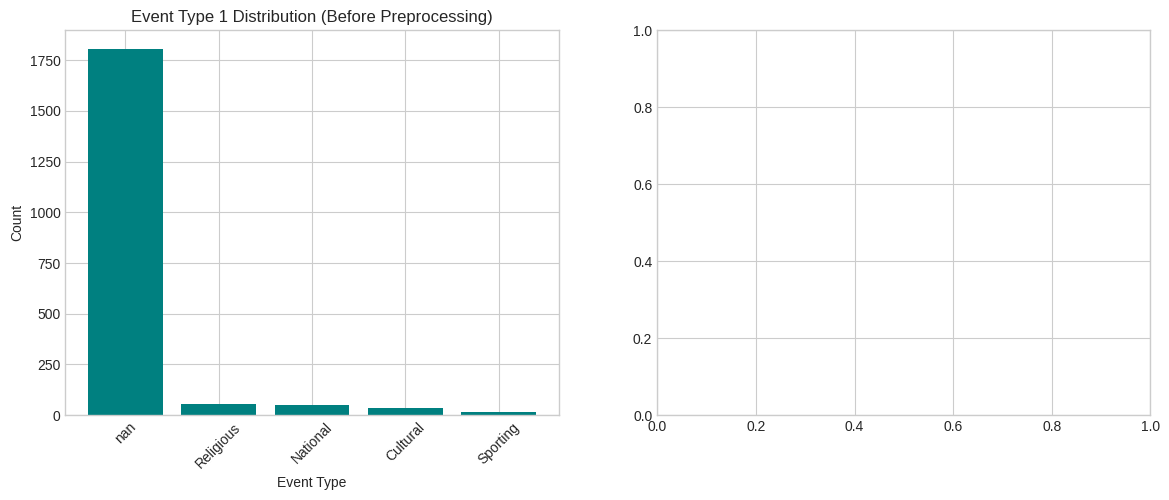

In [12]:
# 2.4 Event distribution before preprocessing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Event type 1 distribution
event_type_1_counts = calendar['event_type_1'].value_counts(dropna=False)
axes[0].bar(event_type_1_counts.index.astype(str), event_type_1_counts.values, color='teal')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Event Type 1 Distribution (Before Preprocessing)')
axes[0].tick_params(axis='x', rotation=45)

In [13]:
# Weekday distribution
weekday_counts = calendar['weekday'].value_counts()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = weekday_counts.reindex(weekday_order)
axes[1].bar(weekday_counts.index, weekday_counts.values, color='purple')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Count')
axes[1].set_title('Weekday Distribution (Before Preprocessing)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('calendar_events_before.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

### SECTION 3: PREPROCESSING

In [15]:
# Create a copy for preprocessing
calendar_processed = calendar.copy()

In [16]:
# 3.1 Convert date to datetime
print("\n--- Step 1: Date Conversion ---")
calendar_processed['date'] = pd.to_datetime(calendar_processed['date'])
print(f"Date type after conversion: {calendar_processed['date'].dtype}")
print(f"Date range: {calendar_processed['date'].min()} to {calendar_processed['date'].max()}")


--- Step 1: Date Conversion ---
Date type after conversion: datetime64[ns]
Date range: 2011-01-29 00:00:00 to 2016-06-19 00:00:00


In [17]:
# 3.2 Extract temporal features
print("\n--- Step 2: Temporal Feature Extraction ---")
calendar_processed['year'] = calendar_processed['date'].dt.year
calendar_processed['month'] = calendar_processed['date'].dt.month
calendar_processed['day'] = calendar_processed['date'].dt.day
calendar_processed['day_of_week'] = calendar_processed['date'].dt.dayofweek  # Monday=0
calendar_processed['day_of_year'] = calendar_processed['date'].dt.dayofyear
calendar_processed['week_of_year'] = calendar_processed['date'].dt.isocalendar().week.astype(int)
calendar_processed['quarter'] = calendar_processed['date'].dt.quarter
calendar_processed['is_weekend'] = (calendar_processed['day_of_week'] >= 5).astype(int)

print("Temporal features added: year, month, day, day_of_week, day_of_year, week_of_year, quarter, is_weekend")


--- Step 2: Temporal Feature Extraction ---
Temporal features added: year, month, day, day_of_week, day_of_year, week_of_year, quarter, is_weekend


In [18]:
# 3.3 Handle event columns
print("\n--- Step 3: Event Column Handling ---")
event_cols = ['event_name_1', 'event_name_2', 'event_type_1', 'event_type_2']
for col in event_cols:
    null_count = calendar_processed[col].isnull().sum()
    calendar_processed[col] = calendar_processed[col].fillna('None')
    print(f"  {col}: Filled {null_count} null values with 'None'")


--- Step 3: Event Column Handling ---
  event_name_1: Filled 1807 null values with 'None'
  event_name_2: Filled 1964 null values with 'None'
  event_type_1: Filled 1807 null values with 'None'
  event_type_2: Filled 1964 null values with 'None'


In [19]:
# 3.4 Create event indicators
print("\n--- Step 4: Event Indicators ---")
calendar_processed['has_event_1'] = (calendar_processed['event_name_1'] != 'None').astype(int)
calendar_processed['has_event_2'] = (calendar_processed['event_name_2'] != 'None').astype(int)
calendar_processed['total_events'] = calendar_processed['has_event_1'] + calendar_processed['has_event_2']
calendar_processed['has_any_event'] = (calendar_processed['total_events'] > 0).astype(int)

print(f"Days with at least one event: {calendar_processed['has_any_event'].sum()}")
print(f"Percentage of days with events: {calendar_processed['has_any_event'].mean()*100:.2f}%")


--- Step 4: Event Indicators ---
Days with at least one event: 162
Percentage of days with events: 8.23%


In [20]:
# 3.5 Create major holiday indicator
major_holidays = ['Christmas', 'Thanksgiving', 'New Year', 'Easter', 'Halloween']
calendar_processed['is_major_holiday'] = calendar_processed['event_name_1'].isin(major_holidays).astype(int)
print(f"Major holiday days: {calendar_processed['is_major_holiday'].sum()}")

Major holiday days: 20


In [21]:
# 3.6 Ensure SNAP columns are integers
snap_cols = ['snap_CA', 'snap_TX', 'snap_WI']
for col in snap_cols:
    calendar_processed[col] = calendar_processed[col].astype(int)

In [22]:
# 3.7 Sort by date and create day index
calendar_processed = calendar_processed.sort_values('date').reset_index(drop=True)
calendar_processed['day_index'] = calendar_processed['d'].str.replace('d_', '').astype(int)

print(f"\nDay index range: {calendar_processed['day_index'].min()} to {calendar_processed['day_index'].max()}")


Day index range: 1 to 1969


### SECTION 4: OUTLIER DETECTION AND HANDLING

In [23]:
def detect_calendar_outliers(df):
    """Detect and handle outliers in calendar dataset"""
    df_clean = df.copy()
    issues_found = []

    # 1. SNAP Columns Validation
    print("\n1. SNAP Columns Validation")
    print("-" * 40)
    for col in ['snap_CA', 'snap_TX', 'snap_WI']:
        unique_vals = df_clean[col].unique()
        invalid_vals = [x for x in unique_vals if x not in [0, 1]]
        if invalid_vals:
            print(f"  ⚠️ Invalid values in {col}: {invalid_vals}")
            df_clean[col] = df_clean[col].apply(lambda x: 1 if x == 1 else 0)
            issues_found.append(f"Fixed invalid values in {col}")
        else:
            print(f"  ✅ {col} has valid binary values")

    # 2. Date Continuity Check
    print("\n2. Date Continuity Check")
    print("-" * 40)
    date_diff = df_clean['date'].diff().dt.days
    gaps = date_diff[date_diff > 1]
    if len(gaps) > 0:
        print(f"  ⚠️ Found {len(gaps)} gaps in date sequence")
        issues_found.append(f"Found {len(gaps)} date gaps")
    else:
        print("  ✅ No gaps in date sequence")

    # 3. Weekday Validation
    print("\n3. Weekday Validation")
    print("-" * 40)
    expected_dow = df_clean['date'].dt.dayofweek
    actual_dow = df_clean['wday'] - 1
    mismatches = (expected_dow != actual_dow).sum()
    if mismatches > 0:
        print(f"  ⚠️ Found {mismatches} day-of-week mismatches")
        issues_found.append(f"Found {mismatches} day-of-week mismatches")
    else:
        print("  ✅ All day-of-week values are correct")

    # 4. Duplicate Date Check
    print("\n4. Duplicate Date Check")
    print("-" * 40)
    duplicates = df_clean['date'].duplicated().sum()
    if duplicates > 0:
        print(f"  ⚠️ Found {duplicates} duplicate dates")
        df_clean = df_clean.drop_duplicates(subset=['date'], keep='first')
        issues_found.append(f"Removed {duplicates} duplicate dates")
    else:
        print("  ✅ No duplicate dates found")

    return df_clean, issues_found

calendar_cleaned, calendar_issues = detect_calendar_outliers(calendar_processed)


1. SNAP Columns Validation
----------------------------------------
  ✅ snap_CA has valid binary values
  ✅ snap_TX has valid binary values
  ✅ snap_WI has valid binary values

2. Date Continuity Check
----------------------------------------
  ✅ No gaps in date sequence

3. Weekday Validation
----------------------------------------
  ⚠️ Found 1969 day-of-week mismatches

4. Duplicate Date Check
----------------------------------------
  ✅ No duplicate dates found


### SECTION 5: VISUALIZATION AFTER PREPROCESSING

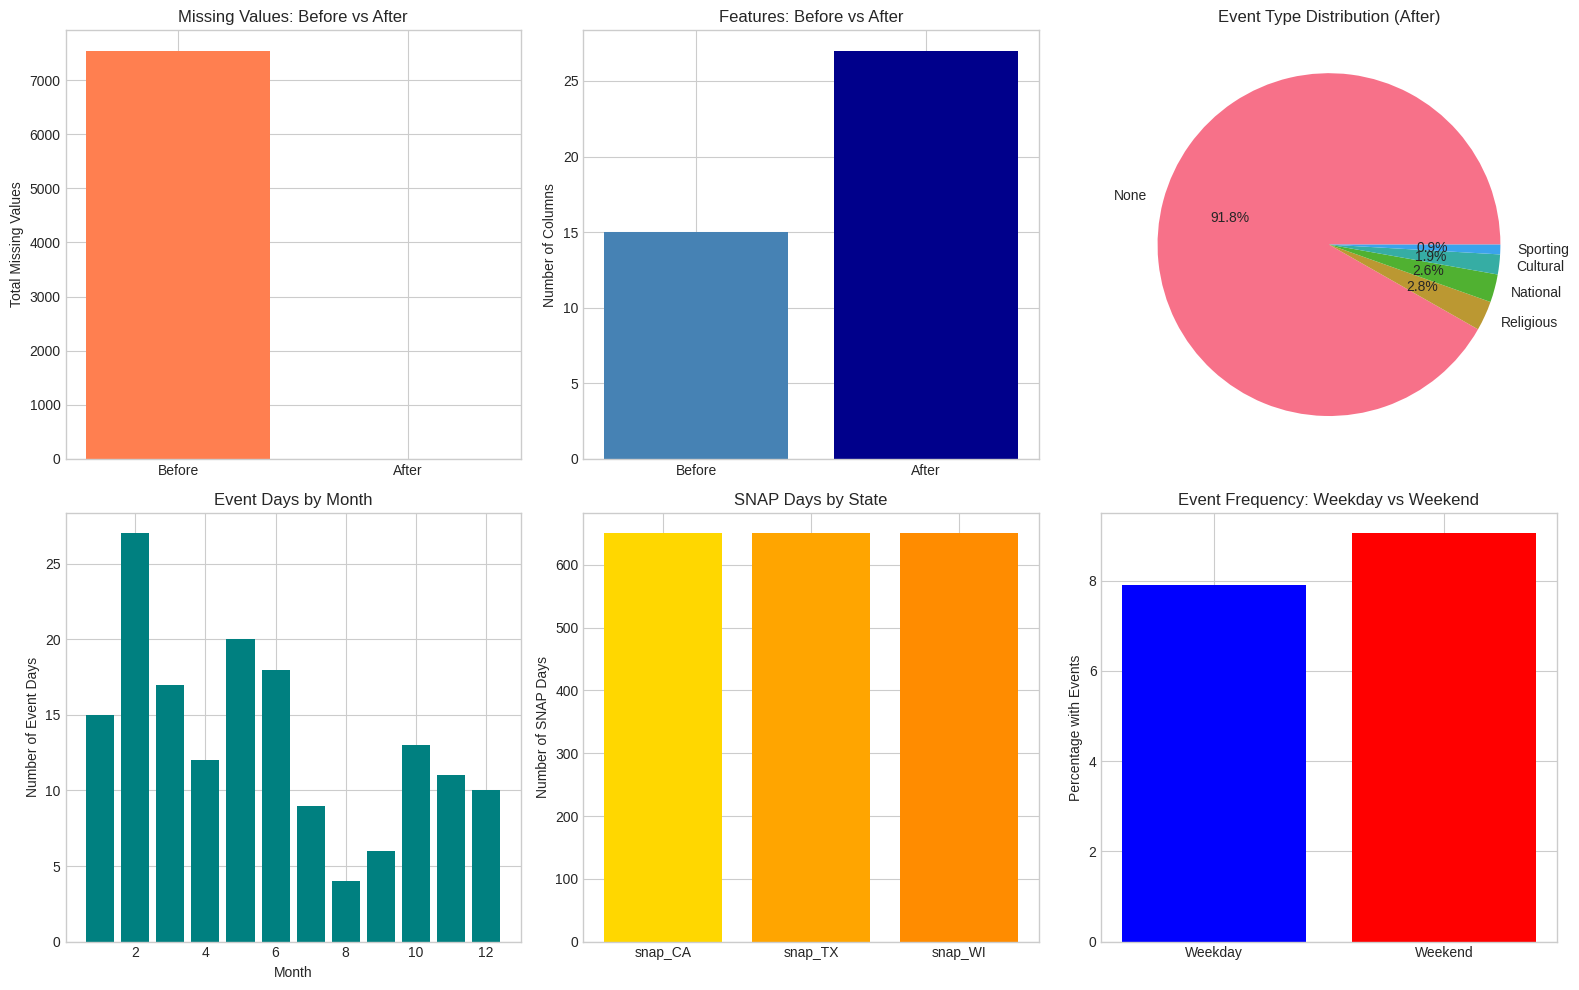

In [24]:
# 5.1 Before vs After Comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Missing values comparison
missing_before = calendar.isnull().sum().sum()
missing_after = calendar_cleaned.isnull().sum().sum()
axes[0, 0].bar(['Before', 'After'], [missing_before, missing_after], color=['coral', 'green'])
axes[0, 0].set_ylabel('Total Missing Values')
axes[0, 0].set_title('Missing Values: Before vs After')

# Number of columns
cols_before = len(calendar.columns)
cols_after = len(calendar_cleaned.columns)
axes[0, 1].bar(['Before', 'After'], [cols_before, cols_after], color=['steelblue', 'darkblue'])
axes[0, 1].set_ylabel('Number of Columns')
axes[0, 1].set_title('Features: Before vs After')

# Event type distribution after
event_counts = calendar_cleaned['event_type_1'].value_counts()
axes[0, 2].pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%')
axes[0, 2].set_title('Event Type Distribution (After)')

# Monthly event distribution
monthly_events = calendar_cleaned.groupby('month')['has_any_event'].sum()
axes[1, 0].bar(monthly_events.index, monthly_events.values, color='teal')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Event Days')
axes[1, 0].set_title('Event Days by Month')

# SNAP distribution
snap_data = calendar_cleaned[['snap_CA', 'snap_TX', 'snap_WI']].sum()
axes[1, 1].bar(snap_data.index, snap_data.values, color=['gold', 'orange', 'darkorange'])
axes[1, 1].set_ylabel('Number of SNAP Days')
axes[1, 1].set_title('SNAP Days by State')

# Weekend vs Weekday events
weekend_events = calendar_cleaned.groupby('is_weekend')['has_any_event'].mean()
axes[1, 2].bar(['Weekday', 'Weekend'], weekend_events.values * 100, color=['blue', 'red'])
axes[1, 2].set_ylabel('Percentage with Events')
axes[1, 2].set_title('Event Frequency: Weekday vs Weekend')

plt.tight_layout()
plt.savefig('calendar_after_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

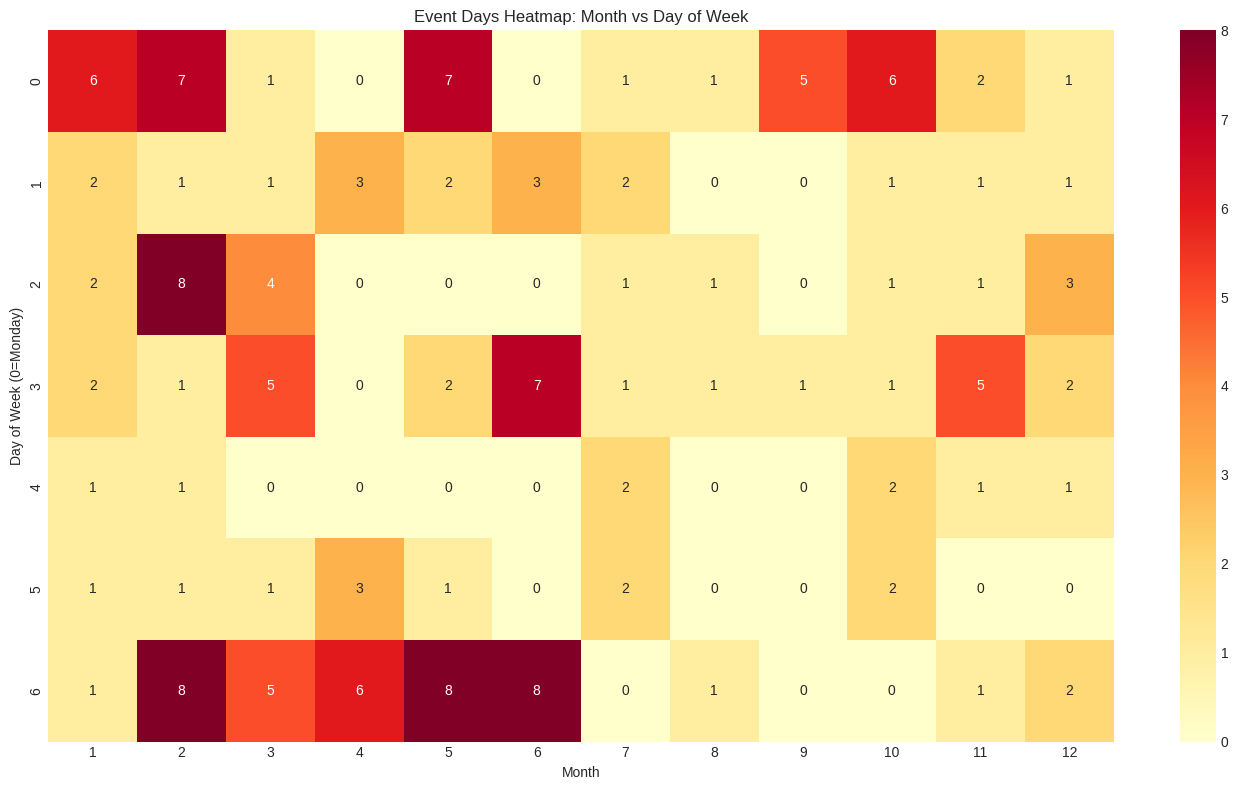

In [25]:
# 5.2 Temporal patterns heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Create pivot table for month vs day_of_week events
event_pivot = calendar_cleaned.pivot_table(
    values='has_any_event',
    index='day_of_week',
    columns='month',
    aggfunc='sum'
)

sns.heatmap(event_pivot, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Day of Week (0=Monday)')
ax.set_title('Event Days Heatmap: Month vs Day of Week')

plt.tight_layout()
plt.savefig('calendar_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### SECTION 6: KEY METRICS FROM PREPROCESSED DATA

In [26]:
metrics = {
    'Total Days': len(calendar_cleaned),
    'Date Range': f"{calendar_cleaned['date'].min().date()} to {calendar_cleaned['date'].max().date()}",
    'Total Features': len(calendar_cleaned.columns),
    'Original Features': len(calendar.columns),
    'New Features Added': len(calendar_cleaned.columns) - len(calendar.columns),
    'Days with Events': calendar_cleaned['has_any_event'].sum(),
    'Event Days Percentage': f"{calendar_cleaned['has_any_event'].mean()*100:.2f}%",
    'Major Holidays': calendar_cleaned['is_major_holiday'].sum(),
    'Weekend Days': calendar_cleaned['is_weekend'].sum(),
    'SNAP Days CA': calendar_cleaned['snap_CA'].sum(),
    'SNAP Days TX': calendar_cleaned['snap_TX'].sum(),
    'SNAP Days WI': calendar_cleaned['snap_WI'].sum(),
    'Unique Event Types': calendar_cleaned['event_type_1'].nunique(),
    'Unique Events': calendar_cleaned['event_name_1'].nunique()
}

print("\n--- Summary Metrics ---")
for key, value in metrics.items():
    print(f"  {key}: {value}")


--- Summary Metrics ---
  Total Days: 1969
  Date Range: 2011-01-29 to 2016-06-19
  Total Features: 27
  Original Features: 15
  New Features Added: 12
  Days with Events: 162
  Event Days Percentage: 8.23%
  Major Holidays: 20
  Weekend Days: 564
  SNAP Days CA: 650
  SNAP Days TX: 650
  SNAP Days WI: 650
  Unique Event Types: 5
  Unique Events: 31


In [27]:
# Save cleaned dataset
calendar_cleaned.to_csv('/content/drive/MyDrive/IRP/M5 Forecasting dataset/calendar_cleaned.csv', index=False)
print("\n✅ Cleaned calendar dataset saved!")


✅ Cleaned calendar dataset saved!


### SECTION 7: HALLUCINATION DETECTION (DATA QUALITY CHECKS)

In [28]:
def detect_calendar_hallucinations(df):
    """Detect potential hallucinations/data quality issues"""
    hallucinations = {'temporal': [], 'causal': [], 'entity': []}

    # Temporal checks
    print("\n1. TEMPORAL CHECKS")
    print("-" * 40)

    # Date continuity
    date_diff = df['date'].diff().dt.days
    gaps = date_diff[date_diff > 1]
    if len(gaps) > 0:
        hallucinations['temporal'].append({'type': 'date_gaps', 'count': len(gaps)})
        print(f"  ⚠️ {len(gaps)} date gaps found")
    else:
        print("  ✅ No date gaps")

    # Day-of-week consistency
    expected_dow = df['date'].dt.dayofweek
    actual_dow = df['wday'] - 1
    mismatches = (expected_dow != actual_dow).sum()
    if mismatches > 0:
        hallucinations['temporal'].append({'type': 'dow_mismatch', 'count': mismatches})
        print(f"  ⚠️ {mismatches} day-of-week mismatches")
    else:
        print("  ✅ Day-of-week values are consistent")

    # Causal checks
    print("\n2. CAUSAL CHECKS")
    print("-" * 40)

    # Event-SNAP independence
    if 'has_any_event' in df.columns:
        corr = df[['has_any_event', 'snap_CA']].corr().iloc[0, 1]
        print(f"  Event-SNAP correlation: {corr:.3f}")
        if abs(corr) > 0.3:
            hallucinations['causal'].append({'type': 'event_snap_correlation', 'value': corr})
            print("  ⚠️ High correlation detected")
        else:
            print("  ✅ Events and SNAP are independent")

    # Entity checks
    print("\n3. ENTITY CHECKS")
    print("-" * 40)

    # D-column format
    invalid_d = df[~df['d'].str.match(r'^d_\d+$')]
    if len(invalid_d) > 0:
        hallucinations['entity'].append({'type': 'invalid_d_format', 'count': len(invalid_d)})
        print(f"  ⚠️ {len(invalid_d)} invalid d format entries")
    else:
        print("  ✅ All d entries have valid format")

    return hallucinations

calendar_hallucinations = detect_calendar_hallucinations(calendar_cleaned)


1. TEMPORAL CHECKS
----------------------------------------
  ✅ No date gaps
  ⚠️ 1969 day-of-week mismatches

2. CAUSAL CHECKS
----------------------------------------
  Event-SNAP correlation: 0.014
  ✅ Events and SNAP are independent

3. ENTITY CHECKS
----------------------------------------
  ✅ All d entries have valid format


In [29]:
# Summary
print("\n" + "=" * 80)
print("CALENDAR PREPROCESSING COMPLETE")
print("=" * 80)
print(f"\nFinal shape: {calendar_cleaned.shape}")
print(f"Issues found and fixed: {len(calendar_issues)}")
print(f"Hallucinations detected: {sum(len(v) for v in calendar_hallucinations.values())}")


CALENDAR PREPROCESSING COMPLETE

Final shape: (1969, 27)
Issues found and fixed: 1
Hallucinations detected: 1
